In [ ]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `tools.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# Análise de Erros — Taxonomia de Erros do Melhor Modelo

Este notebook implementa a análise qualitativa e quantitativa de erros do melhor modelo (GPT-4-turbo) no conjunto de teste do dataset **decicontas.br**, destinada à seção *Análise de Erros* do TCC.

A análise classifica cada discrepância entre spans preditos e spans gold em cinco categorias:

1. **Falso positivo** — span predito sem correspondência no gold
2. **Falso negativo** — span gold não detectado pelo modelo
3. **Fronteira incorreta** — sobreposição com rótulo correto, mas IoU < 1
4. **Tipo errado** — sobreposição, mas rótulo diferente
5. **Outro** — saída malformada, fuzzy match insuficiente, etc.

Ao final, são gerados:
- Tabela de taxonomia (texto + LaTeX)
- Distribuição cruzada rótulo × tipo de erro
- Matriz de confusão para erros de tipo errado
- Exemplos qualitativos prontos para o texto

## 1. Imports e configuração

In [18]:
import json
import textwrap
from collections import defaultdict
from dataclasses import dataclass

import pandas as pd
from rapidfuzz import fuzz

# ── Configuração ──
MODEL_NAME = "gpt-4-turbo"                    # melhor modelo
RESULTS_DIR = "dataset/"            # diretório dos JSONs
N_EXAMPLES = 3                                  # exemplos qualitativos por tipo

MODELS_NAMES = [
    "gpt-41", "gpt-41-nano", "gpt-41-mini",
    "gpt-35", "gpt-4o", "gpt-4-turbo"
]

## 2. Mapeamento de rótulos

Mesma lógica utilizada em `tools/dataset.py` e no notebook `ner.ipynb`.

In [23]:
# Pred keys → rótulo padronizado
DICT_LABELS = {
    "obrigacoes": "OBRIGACAO",
    "recomendacoes": "RECOMENDACAO",
    "ressarcimentos": "RESSARCIMENTO",
    "multas": "MULTA",
}

# Gold labels que precisam de tradução
DICT_LABELS_GOLDEN = {
    "MULTA_FIXA": "MULTA",
    "MULTA_PERCENTUAL": "MULTA",
    "OBRIGACAO_MULTA": "OBRIGACAO",
}

## 3. Carregamento dos dados

Carrega o JSON de resultados do modelo selecionado (mesmo formato gerado pelo `ner.ipynb`).

In [24]:
results_file = f"{RESULTS_DIR}/results/output/models_results_decicontas_{MODEL_NAME}.json"
print(f"Carregando: {results_file}")

with open(results_file, "r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f"Documentos carregados: {len(df)}")
df.head()

Carregando: dataset//results/output/models_results_decicontas_gpt-4-turbo.json
Documentos carregados: 866


,index,text,pred,golden,model
0,3,DECIDEM os Conselheiros do Tribunal de Contas ...,"{'multas': [], 'ressarcimentos': [], 'obrigaco...",[],gpt-4-turbo
1,136,DECIDEM os Conselheiros do Tribunal de Contas ...,"{'multas': [], 'ressarcimentos': [], 'obrigaco...",[],gpt-4-turbo
2,152,DECIDEM os Conselheiros do Tribunal de Contas ...,"{'multas': [], 'ressarcimentos': [], 'obrigaco...",[],gpt-4-turbo
3,5,"Vistos, relatados e discutidos estes autos, ac...","{'multas': [], 'ressarcimentos': [], 'obrigaco...",[],gpt-4-turbo
4,6,DECIDEM os Conselheiros do Tribunal de Contas ...,"{'multas': [], 'ressarcimentos': [], 'obrigaco...",[],gpt-4-turbo


## 4. Conversão de predições para spans

Reutiliza a mesma lógica de `convert_pred_to_golden_format` do `ner.ipynb`, com uma adição: registra também os spans que **não puderam ser localizados** no texto (serão classificados como erros da categoria "Outro").

In [25]:
def convert_pred_to_spans(pred: dict, text: str,
                          window_size=500, step_size=100, min_score=80):
    """
    Converte a saída estruturada do modelo em spans (start, end, text, labels).
    Retorna:
        found_spans:    lista de dicts com spans localizados
        unlocated_spans: lista de dicts com spans não encontrados no texto
    """
    found_spans = []
    unlocated_spans = []

    for label_type, spans in pred.items():
        if label_type not in DICT_LABELS:
            continue
        for span in spans:
            if not isinstance(span, dict):
                unlocated_spans.append({
                    "label": DICT_LABELS[label_type],
                    "raw": str(span)[:200],
                    "reason": "span não é dicionário (saída malformada)"
                })
                continue

            span_text = (
                span.get("descricao_multa")
                or span.get("descricao_obrigacao")
                or span.get("descricao_ressarcimento")
                or span.get("descricao_recomendacao")
            )
            if not span_text:
                unlocated_spans.append({
                    "label": DICT_LABELS[label_type],
                    "raw": str(span)[:200],
                    "reason": "campo de descrição vazio"
                })
                continue

            best_score = 0
            best_pos = -1
            best_substring = ""

            for start in range(0, len(text), step_size):
                window = text[start: start + window_size]
                score = fuzz.partial_ratio(span_text, window)
                if score > best_score and score >= min_score:
                    best_score = score
                    words = span_text.split()
                    first_word_pos = window.find(words[0]) if words else 0
                    best_pos = start + (first_word_pos if first_word_pos >= 0 else 0)
                    best_substring = span_text

            if best_score >= min_score and best_pos >= 0:
                found_spans.append({
                    "start": best_pos,
                    "end": best_pos + len(best_substring),
                    "text": best_substring,
                    "labels": [DICT_LABELS[label_type]],
                })
            else:
                unlocated_spans.append({
                    "label": DICT_LABELS[label_type],
                    "raw": span_text[:120],
                    "reason": f"fuzzy match insuficiente (melhor score={best_score})"
                })

    return found_spans, unlocated_spans

## 5. Funções de IoU e sobreposição

In [26]:
def compute_iou(s1, e1, s2, e2):
    """IoU entre dois intervalos [s, e)."""
    inter = max(0, min(e1, e2) - max(s1, s2))
    union = max(e1, e2) - min(s1, s2)
    return inter / union if union > 0 else 0.0


def has_overlap(s1, e1, s2, e2):
    return not (e1 <= s2 or e2 <= s1)

## 6. Classificação de erros

Para cada documento, alinha spans preditos com spans gold usando **matching guloso** ordenado por IoU decrescente (mesmo princípio do `calculate_metrics`), e classifica cada discrepância.

In [27]:
@dataclass
class ErrorRecord:
    tipo: str            # "FP", "FN", "FRONTEIRA", "TIPO_ERRADO", "OUTRO"
    label_pred: str = ""
    label_gold: str = ""
    text_pred: str = ""
    text_gold: str = ""
    iou: float = 0.0
    doc_index: int = -1
    context: str = ""


def classify_errors(gold_spans, pred_spans, unlocated, text, doc_index):
    """
    Alinha pred ↔ gold e classifica cada discrepância.
    Retorna lista de ErrorRecord.
    """
    errors = []

    # ── 1. 'Outro': spans não localizados no texto ──
    for u in unlocated:
        errors.append(ErrorRecord(
            tipo="OUTRO",
            label_pred=u["label"],
            text_pred=u["raw"][:200],
            doc_index=doc_index,
            context=u["reason"],
        ))

    # ── 2. Calcular todas as sobreposições ──
    overlaps = []
    for pi, p in enumerate(pred_spans):
        for gi, g in enumerate(gold_spans):
            if has_overlap(p["start"], p["end"], g["start"], g["end"]):
                iou = compute_iou(p["start"], p["end"], g["start"], g["end"])
                overlaps.append((iou, pi, gi))

    # Matching guloso por IoU decrescente
    overlaps.sort(key=lambda x: -x[0])
    gold_matched = set()
    pred_matched = set()

    for iou_val, pi, gi in overlaps:
        if pi in pred_matched or gi in gold_matched:
            continue
        p = pred_spans[pi]
        g = gold_spans[gi]
        label_p = p["labels"][0]
        label_g = g["labels"][0]

        pred_matched.add(pi)
        gold_matched.add(gi)

        if label_p == label_g and iou_val >= 1.0 - 1e-6:
            pass  # Match perfeito — não é erro
        elif label_p != label_g:
            errors.append(ErrorRecord(
                tipo="TIPO_ERRADO",
                label_pred=label_p, label_gold=label_g,
                text_pred=p.get("text", "")[:200],
                text_gold=text[g["start"]:g["end"]][:200],
                iou=iou_val, doc_index=doc_index,
            ))
        else:
            errors.append(ErrorRecord(
                tipo="FRONTEIRA",
                label_pred=label_p, label_gold=label_g,
                text_pred=p.get("text", "")[:200],
                text_gold=text[g["start"]:g["end"]][:200],
                iou=iou_val, doc_index=doc_index,
            ))

    # ── 3. Pred não pareado → Falso positivo ──
    for pi, p in enumerate(pred_spans):
        if pi not in pred_matched:
            errors.append(ErrorRecord(
                tipo="FP",
                label_pred=p["labels"][0],
                text_pred=p.get("text", "")[:200],
                doc_index=doc_index,
            ))

    # ── 4. Gold não pareado → Falso negativo ──
    for gi, g in enumerate(gold_spans):
        if gi not in gold_matched:
            errors.append(ErrorRecord(
                tipo="FN",
                label_gold=g["labels"][0],
                text_gold=text[g["start"]:g["end"]][:200],
                doc_index=doc_index,
            ))

    return errors

## 7. Execução da análise

Percorre todos os documentos do conjunto de teste, converte as predições, e classifica os erros.

In [28]:
all_errors = []
total_gold = 0
total_pred = 0
total_perfect = 0

for rec in records:
    text = rec["text"]
    doc_index = rec["index"]

    # Gold spans (com tradução de labels)
    gold_spans = rec.get("golden", [])
    for g in gold_spans:
        g["labels"] = [DICT_LABELS_GOLDEN.get(g["labels"][0], g["labels"][0])]

    # Pred spans
    pred_raw = rec.get("pred", {})
    pred_spans, unlocated = convert_pred_to_spans(pred_raw, text)

    total_gold += len(gold_spans)
    total_pred += len(pred_spans)

    # Classificar erros
    doc_errors = classify_errors(gold_spans, pred_spans, unlocated, text, doc_index)
    all_errors.extend(doc_errors)

    # Contar matches perfeitos
    n_fp = len([e for e in doc_errors if e.tipo == "FP"])
    n_partial = len([e for e in doc_errors if e.tipo in ("FRONTEIRA", "TIPO_ERRADO")])
    n_matched = len(pred_spans) - n_fp - n_partial
    total_perfect += max(0, n_matched)

print(f"Spans gold (total):      {total_gold}")
print(f"Spans preditos (total):  {total_pred}")
print(f"Matches perfeitos:       {total_perfect}")
print(f"Total de erros:          {len(all_errors)}")

Spans gold (total):      441
Spans preditos (total):  551
Matches perfeitos:       55
Total de erros:          535


## 8. Tabela de taxonomia de erros

In [30]:
TIPO_DISPLAY = {
    "FP": "Falso positivo (entidade inexistente)",
    "FN": "Falso negativo (entidade não detectada)",
    "FRONTEIRA": "Fronteira incorreta (span parcial)",
    "TIPO_ERRADO": "Tipo errado (confusão entre categorias)",
    "OUTRO": "Outro",
}
TIPO_ORDER = ["FP", "FN", "FRONTEIRA", "TIPO_ERRADO", "OUTRO"]

counts = defaultdict(int)
for e in all_errors:
    counts[e.tipo] += 1
total = sum(counts.values())

rows = []
for t in TIPO_ORDER:
    c = counts.get(t, 0)
    pct = 100 * c / total if total > 0 else 0
    rows.append({"Tipo de Erro": TIPO_DISPLAY[t], "Frequência": c, "% do Total": f"{pct:.1f}%"})
rows.append({"Tipo de Erro": "Total", "Frequência": total, "% do Total": "100,0%"})

df_taxonomy = pd.DataFrame(rows)
df_taxonomy

,Tipo de Erro,Frequência,% do Total
0,Falso positivo (entidade inexistente),147,27.5%
1,Falso negativo (entidade não detectada),37,6.9%
2,Fronteira incorreta (span parcial),343,64.1%
3,Tipo errado (confusão entre categorias),6,1.1%
4,Outro,2,0.4%
5,Total,535,"100,0%"


In [38]:
df_taxonomy.to_markdown('dataset/results/experiments/errors/error_taxonomy.md', index=False)

## 9. Distribuição por rótulo × tipo de erro

In [32]:
label_tipo = defaultdict(lambda: defaultdict(int))
for e in all_errors:
    label = e.label_pred or e.label_gold or "?"
    label_tipo[label][e.tipo] += 1

cross_rows = []
for lab in sorted(label_tipo.keys()):
    row = {"Rótulo": lab}
    row_total = 0
    for t in TIPO_ORDER:
        v = label_tipo[lab][t]
        row[TIPO_DISPLAY[t]] = v
        row_total += v
    row["Total"] = row_total
    cross_rows.append(row)

df_cross = pd.DataFrame(cross_rows)
df_cross.set_index("Rótulo", inplace=True)
df_cross

,Falso positivo (entidade inexistente),Falso negativo (entidade não detectada),Fronteira incorreta (span parcial),Tipo errado (confusão entre categorias),Outro,Total
Rótulo,,,,,,
MULTA,34,14,168,6,2,224
OBRIGACAO,59,19,94,0,0,172
RECOMENDACAO,35,3,28,0,0,66
RESSARCIMENTO,19,1,53,0,0,73


In [39]:
df_cross.to_markdown('dataset/results/experiments/errors/error_cross.md', index=False)

## 10. Matriz de confusão (erros de tipo errado)

Mostra quais pares de rótulos são mais frequentemente confundidos pelo modelo.

In [33]:
tipo_errado = [e for e in all_errors if e.tipo == "TIPO_ERRADO"]

if tipo_errado:
    confusion = defaultdict(lambda: defaultdict(int))
    for e in tipo_errado:
        confusion[e.label_gold][e.label_pred] += 1

    all_labels = sorted(set(
        [e.label_gold for e in tipo_errado] + [e.label_pred for e in tipo_errado]
    ))

    matrix_rows = []
    for g in all_labels:
        row = {"Gold \\ Pred": g}
        for p in all_labels:
            row[p] = confusion[g][p]
        matrix_rows.append(row)

    df_confusion = pd.DataFrame(matrix_rows).set_index("Gold \\ Pred")
    display(df_confusion)
else:
    print("Nenhum erro de tipo errado encontrado.")

,MULTA,OBRIGACAO,RESSARCIMENTO
Gold \ Pred,,,
MULTA,0,0,0
OBRIGACAO,1,0,0
RESSARCIMENTO,5,0,0


In [43]:
df_confusion.to_markdown('dataset/results/experiments/errors/error_confusion_matrix.md', index=True)

## 11. Distribuição de IoU nos erros de fronteira

Histograma dos valores de IoU nos erros de fronteira incorreta, para entender se os erros são sobreposições marginais ou desvios grandes.

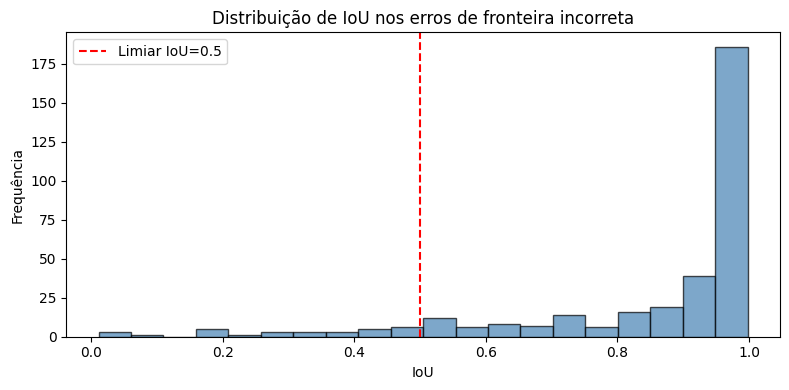

IoU médio (fronteira): 0.8518
IoU mediano:           0.9529


In [34]:
import matplotlib.pyplot as plt

fronteira_ious = [e.iou for e in all_errors if e.tipo == "FRONTEIRA"]

if fronteira_ious:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(fronteira_ious, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel('IoU')
    ax.set_ylabel('Frequência')
    ax.set_title('Distribuição de IoU nos erros de fronteira incorreta')
    ax.axvline(x=0.5, color='red', linestyle='--', label='Limiar IoU=0.5')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"IoU médio (fronteira): {sum(fronteira_ious)/len(fronteira_ious):.4f}")
    print(f"IoU mediano:           {sorted(fronteira_ious)[len(fronteira_ious)//2]:.4f}")
else:
    print("Nenhum erro de fronteira encontrado.")

## 12. Exemplos qualitativos

Seleciona os primeiros exemplos de cada tipo de erro, com os trechos preditos e gold para uso direto no texto do TCC.

In [35]:
for t in TIPO_ORDER:
    subset = [e for e in all_errors if e.tipo == t]
    if not subset:
        continue
    print(f"\n{'═' * 70}")
    print(f"  {TIPO_DISPLAY[t]}  ({len(subset)} ocorrências)")
    print(f"{'═' * 70}")
    for i, e in enumerate(subset[:N_EXAMPLES]):
        print(f"\n  ── Exemplo {i+1}  (doc #{e.doc_index}) ──")
        if e.text_pred:
            print(textwrap.fill(e.text_pred, width=90,
                                initial_indent="    PRED: ",
                                subsequent_indent="          "))
            if e.label_pred:
                print(f"    Rótulo predito: {e.label_pred}")
        if e.text_gold:
            print(textwrap.fill(e.text_gold, width=90,
                                initial_indent="    GOLD: ",
                                subsequent_indent="          "))
            if e.label_gold:
                print(f"    Rótulo gold:    {e.label_gold}")
        if e.iou > 0:
            print(f"    IoU: {e.iou:.4f}")
        if e.context:
            print(f"    Nota: {e.context}")


══════════════════════════════════════════════════════════════════════
  Falso positivo (entidade inexistente)  (147 ocorrências)
══════════════════════════════════════════════════════════════════════

  ── Exemplo 1  (doc #186) ──
    PRED: INTIMAÇÃO da referida autoridade competente nominada, a fim de que tome
          conhecimento desta decisão e, se for o caso, apresente recurso no prazo
          regimental.
    Rótulo predito: OBRIGACAO

  ── Exemplo 2  (doc #206) ──
    PRED: Expedição de cientificação ao Conselho de Contabilidade do Rio Grande do Norte –
          CRC/RN, em desfavor da Sr.ª Marijunia Alves Guedes - CRC/RN n.° 7.537/O-6,
          contadora responsável pela entidade no exerc
    Rótulo predito: OBRIGACAO

  ── Exemplo 3  (doc #210) ──
    PRED: multa diária e pessoal à responsável, desde já fixada no valor de R$ 200,00
          (duzentos reais) por dia que superar o interregno aqui fixado, com base no art.
          110 da Lei Complementar Estadual nº 464/20

## 13. Tabela LaTeX pronta para copiar

Gera o código LaTeX da tabela de taxonomia, pronto para substituir o placeholder no `revisao.tex`.

In [36]:
print(r"\begin{table}[ht]")
print(r"    \centering")
print(r"    \caption{Taxonomia de erros do melhor modelo no conjunto de teste.}")
print(r"    \label{tab:taxonomia_erros}")
print(r"    \begin{tabular}{lcc}")
print(r"        \hline")
print(r"        \textbf{Tipo de Erro} & \textbf{Frequência} & \textbf{\% do Total} \\")
print(r"        \hline")
for t in TIPO_ORDER:
    c = counts.get(t, 0)
    pct = 100 * c / total if total > 0 else 0
    display_name = TIPO_DISPLAY[t]
    # Escapar parênteses com itálico para o LaTeX
    display_name_tex = display_name.replace(
        "(entidade inexistente)", r"(\textit{entidade inexistente})"
    ).replace(
        "(entidade não detectada)", r"(\textit{entidade não detectada})"
    ).replace(
        "(span parcial)", r"(\textit{span} parcial)"
    ).replace(
        "(confusão entre categorias)", r"(confusão entre categorias)"
    )
    print(f"        {display_name_tex:<55} & {c} & {pct:.1f}\\% \\\\")
print(r"        \hline")
print(f"        {'\\textbf{Total}':<55} & {total} & 100,0\\% \\\\")
print(r"        \hline")
print(r"    \end{tabular}")
print(r"\end{table}")

\begin{table}[ht]
    \centering
    \caption{Taxonomia de erros do melhor modelo no conjunto de teste.}
    \label{tab:taxonomia_erros}
    \begin{tabular}{lcc}
        \hline
        \textbf{Tipo de Erro} & \textbf{Frequência} & \textbf{\% do Total} \\
        \hline
        Falso positivo (\textit{entidade inexistente})          & 147 & 27.5\% \\
        Falso negativo (\textit{entidade não detectada})        & 37 & 6.9\% \\
        Fronteira incorreta (\textit{span} parcial)             & 343 & 64.1\% \\
        Tipo errado (confusão entre categorias)                 & 6 & 1.1\% \\
        Outro                                                   & 2 & 0.4\% \\
        \hline
        \textbf{Total}                                          & 535 & 100,0\% \\
        \hline
    \end{tabular}
\end{table}


## 14. DataFrame completo de erros (para exploração)

Tabela com todos os erros individuais para filtragem e inspeção manual.

In [37]:
df_errors = pd.DataFrame([
    {
        "doc_index": e.doc_index,
        "tipo": e.tipo,
        "tipo_display": TIPO_DISPLAY[e.tipo],
        "label_pred": e.label_pred,
        "label_gold": e.label_gold,
        "iou": e.iou,
        "text_pred": e.text_pred[:100],
        "text_gold": e.text_gold[:100],
        "context": e.context,
    }
    for e in all_errors
])

print(f"Total de erros: {len(df_errors)}")
df_errors.head(20)

Total de erros: 535


,doc_index,tipo,tipo_display,label_pred,label_gold,iou,text_pred,text_gold,context
0,176,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.997849,"MULTA no valor de R$1.000,00 (mil reais) para ...","MULTA no valor de R$1.000,00 (mil reais) para ...",
1,176,FRONTEIRA,Fronteira incorreta (span parcial),OBRIGACAO,OBRIGACAO,0.964770,RENOVAÇÃO DA DETERMINAÇÃO constante na decisão...,"DETERMINAÇÃO constante na decisão retro, estip...",
2,177,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.970650,"APLICAÇÃO DE MULTA no valor de R$1.000,00 (mil...","MULTA no valor de R$1.000,00 (mil reais) para ...",
3,177,FRONTEIRA,Fronteira incorreta (span parcial),OBRIGACAO,OBRIGACAO,0.952899,RENOVAÇÃO DA DETERMINAÇÃO constante na decisão...,"DETERMINAÇÃO constante na decisão retro, estip...",
4,186,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.995495,"MULTA no valor de R$1.000,00 (mil reais) para ...","MULTA no valor de R$1.000,00 (mil reais) para ...",
5,186,FRONTEIRA,Fronteira incorreta (span parcial),OBRIGACAO,OBRIGACAO,0.965241,RENOVAÇÃO DA DETERMINAÇÃO constante na decisão...,"DETERMINAÇÃO constante na decisão retro, estip...",
6,186,FP,Falso positivo (entidade inexistente),OBRIGACAO,,0.000000,INTIMAÇÃO da referida autoridade competente no...,,
7,188,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.887640,"multa ao Sr. Dagoberto Bessa Cavalcante, respo...","multa ao Sr. Dagoberto Bessa Cavalcante, respo...",
8,189,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.996875,"multa no valor de R$ 36.000,00 (trinta e seis ...","multa no valor de R$ 36.000,00 (trinta e seis ...",
9,189,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.996540,"Multa no valor de R$ 1.600,00 (mil e seiscento...","Multa no valor de R$ 1.600,00 (mil e seiscento...",


### Filtragem interativa

Use as células abaixo para explorar erros específicos.

In [40]:
# Exemplo: filtrar apenas erros de tipo errado envolvendo OBRIGACAO
df_errors[
    (df_errors['tipo'] == 'TIPO_ERRADO') &
    ((df_errors['label_pred'] == 'OBRIGACAO') | (df_errors['label_gold'] == 'OBRIGACAO'))
]

,doc_index,tipo,tipo_display,label_pred,label_gold,iou,text_pred,text_gold,context
295,1083,TIPO_ERRADO,Tipo errado (confusão entre categorias),MULTA,OBRIGACAO,0.179916,"multa diária e pessoal no importe de R$ 1.000,00",medida de proibição ao Município e à gestora r...,


In [41]:
# Exemplo: ver erros de fronteira com IoU mais baixo (piores)
df_errors[df_errors['tipo'] == 'FRONTEIRA'].sort_values('iou').head(10)

,doc_index,tipo,tipo_display,label_pred,label_gold,iou,text_pred,text_gold,context
467,1392,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.011442,"Aplicação de multa no valor total de R$ 1.000,...","multa no valor total de R$ 1.000,00 (um mil re...",
79,338,FRONTEIRA,Fronteira incorreta (span parcial),OBRIGACAO,OBRIGACAO,0.034358,"DETERMINAÇÃO ao órgão previdenciário, no seu a...","DETERMINAÇÃO ao órgão previdenciário, no seu a...",
459,1391,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.040712,"Multa de R$ 600,00 (seiscentos reais), conform...","Multa de R$ 600,00 (seiscentos reais), conform...",
500,1400,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.085213,"multa no valor de R$ 500,00 (quinhentos reais)...","multa no valor de R$ 500,00 (quinhentos reais)...",
234,845,FRONTEIRA,Fronteira incorreta (span parcial),OBRIGACAO,OBRIGACAO,0.167079,"determinando a intimação do IPERN para que, em...","determinando a intimação do IPERN para que, em...",
212,685,FRONTEIRA,Fronteira incorreta (span parcial),RECOMENDACAO,RECOMENDACAO,0.168246,recomendação aos Chefes dos Poderes Municipais...,recomendação aos Chefes dos Poderes Municipais...,
256,908,FRONTEIRA,Fronteira incorreta (span parcial),RECOMENDACAO,RECOMENDACAO,0.177986,recomendar aos Chefes dos Poderes Municipais q...,DECIDE também recomendar aos Chefes dos Podere...,
265,922,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.188406,"multa à Sra. Maria Izabel Araújo Montenegro, n...","MULTA à Sra. Maria Izabel Araújo Montenegro, n...",
76,333,FRONTEIRA,Fronteira incorreta (span parcial),RECOMENDACAO,RECOMENDACAO,0.203226,se recomende à Secretaria de Controle Externo ...,recomende à Secretaria de Controle Externo – S...,
485,1397,FRONTEIRA,Fronteira incorreta (span parcial),MULTA,MULTA,0.236453,"multa no valor de R$ 500,00 (quinhentos reais)...","multa no valor de R$ 1.000,00 (mil reais), pel...",


In [42]:
# Exemplo: inspecionar um documento específico
DOC_ID = 0  # altere para o índice desejado
df_errors[df_errors['doc_index'] == DOC_ID]

,doc_index,tipo,tipo_display,label_pred,label_gold,iou,text_pred,text_gold,context
